In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(50000, 2)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


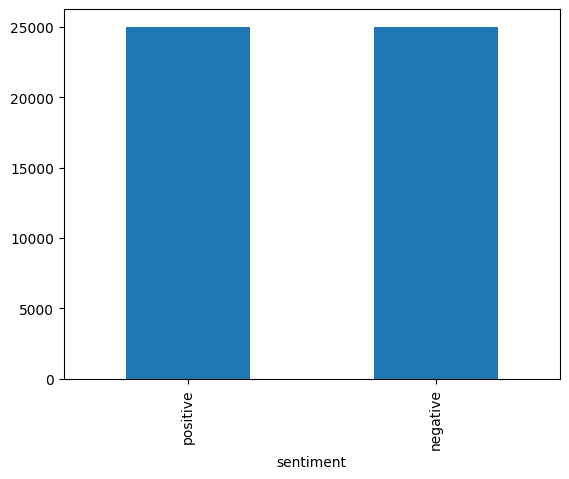

In [ ]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.show()

* Convert Labels to Numeric

In [ ]:
df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


* Remove HTML Tags

In [ ]:
from bs4 import BeautifulSoup

def remove_html(text):
  return BeautifulSoup(text, "html.parser").get_text()

df['review'] = df['review'].apply(remove_html)

* Convert to Lowercase

In [ ]:
df['review'] = df['review'].str.lower()

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Text cleaning
def clean_text(text):
  text = text.lower()
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)# remove links
  text = re.sub(r'[^A-Za-z\s]', '', text) # remove punctuation and numbers
  text = ' '.join(word for word in text.split() if word not in stopwords.words('english'))
  return text

In [ ]:
df['review'] =  df['review'].apply(clean_text)

In [ ]:
df.to_csv('/content/imdb_cleaned.csv', index=False)

In [ ]:
df = pd.read_csv("/content/imdb_cleaned.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/imdb_cleaned.csv'

In [ ]:
df.head()

,review,sentiment
0,one reviewers mentioned watching oz episode yo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically theres family little boy jake thinks...,0
4,petter matteis love time money visually stunni...,1


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional

In [ ]:
# Text preprocessing
def process_text_data(texts, max_words= 10000, max_length=100):
  tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
  tokenizer.fit_on_texts(texts)

  sequences = tokenizer.texts_to_sequences(texts)
  padded_sequences = pad_sequences(sequences,maxlen=max_length, padding='post', truncating='post')

  return padded_sequences, tokenizer

In [ ]:
#Build LSTM model
def build_lstm_model(vocab_size, embedding_dim=64, max_length=100):
    model = Sequential([
        Input(shape=(max_length,)),
        Embedding(vocab_size, embedding_dim),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        Dense(24, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# split the data into training and testing
from sklearn.model_selection import train_test_split

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train_pad, tokenizer = process_text_data(
    X_train,
    max_words=10000,
    max_length=100
)

In [ ]:
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=100,
    padding='post',
    truncating='post'
)

In [ ]:
X_train_pad.shape
X_test_pad.shape

(10000, 100)

In [ ]:
vocab_size = min(
    len(tokenizer.word_index) + 1,
    10000
)

model = build_lstm_model(
    vocab_size=vocab_size,
    embedding_dim=64,
    max_length=100
)

In [ ]:
 model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 748,899 (2.86 MB)

 Trainable params: 748,899 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.7832 - loss: 0.4519 - val_accuracy: 0.8627 - val_loss: 0.3239
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.8901 - loss: 0.2844 - val_accuracy: 0.8602 - val_loss: 0.3280
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9202 - loss: 0.2134 - val_accuracy: 0.8605 - val_loss: 0.3773
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9423 - loss: 0.1603 - val_accuracy: 0.8439 - val_loss: 0.3895
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9554 - loss: 0.1275 - val_accuracy: 0.8506 - val_loss: 0.4184
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9678 - loss: 0.0957 - val_accuracy: 0.8364 - val_loss: 0.5245
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9782 - loss: 0.0695 - val_accuracy: 0.8438 - val_loss: 0.5243
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9829 -

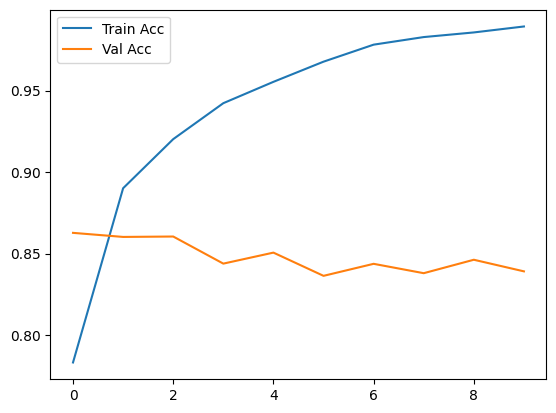

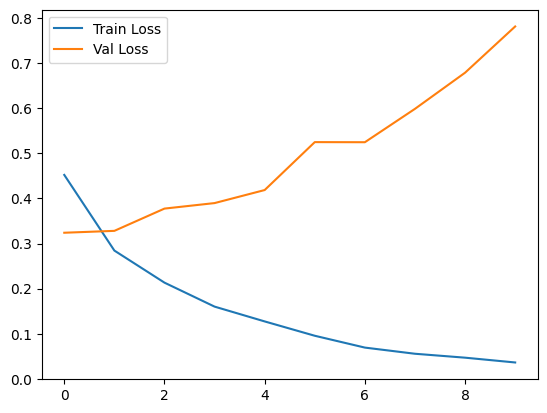

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.7686 - loss: 0.4632 - val_accuracy: 0.8633 - val_loss: 0.3190
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.8934 - loss: 0.2718 - val_accuracy: 0.8547 - val_loss: 0.3365
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9247 - loss: 0.1998 - val_accuracy: 0.8610 - val_loss: 0.3430


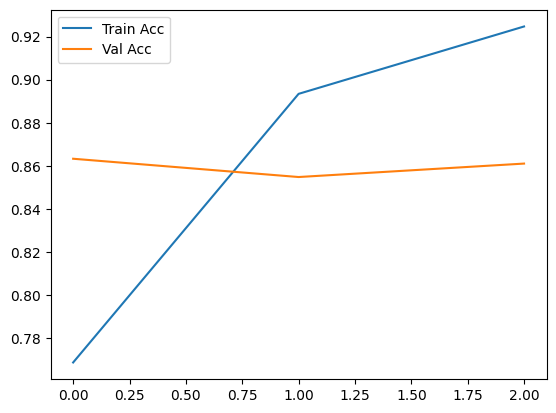

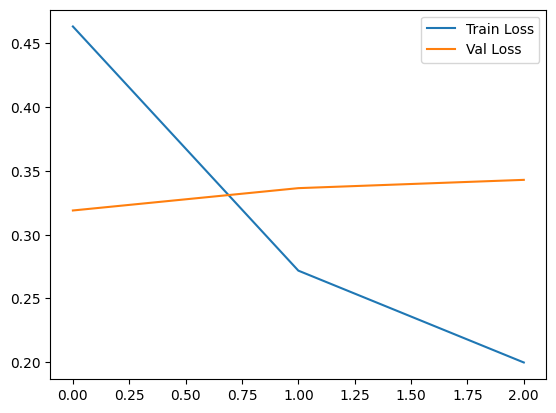

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step


ValueError: Classification metrics can't handle a mix of binary and multilabel-indicator targets